# Agriculture dataset: soil-moisture baseline

This notebook audits the provided CSV and trains an **experimental** XGBoost baseline. It does not replace the production Sentinel/probe pipeline because the source has no farm IDs, timestamps, Sentinel-1 VV/VH, EVI, or NDBI. The raw CSV is read without modification.

In [1]:
from __future__ import annotations

from datetime import datetime, timezone
import hashlib
import json
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
import xgboost as xgb
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42
TARGET = 'Soil_Moisture'
NOTEBOOK_DIR = Path.cwd()
ML_DIR = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == 'notebooks' else NOTEBOOK_DIR
DEFAULT_DATASET = ML_DIR / 'data' / 'agriculture_dataset.csv'
DATASET_PATH = Path(os.environ.get('AGRICULTURE_DATASET_PATH', DEFAULT_DATASET))
MODEL_DIR = ML_DIR / 'models'
MODEL_DIR.mkdir(parents=True, exist_ok=True)

assert DATASET_PATH.is_file(), f'Dataset not found: {DATASET_PATH}'
print(f'Dataset: {DATASET_PATH}')
print(f'pandas={pd.__version__}, sklearn={sklearn.__version__}, xgboost={xgb.__version__}')

Dataset: C:\Users\Lenovo\Desktop\work\KrishiNetra-App\ml\data\agriculture_dataset.csv
pandas=3.0.5, sklearn=1.9.0, xgboost=3.4.1


## 1. Load the raw data

The original file remains in Downloads. No cleaning operation writes back to it.

In [2]:
df_raw = pd.read_csv(DATASET_PATH)
print(f'Rows: {len(df_raw):,}; columns: {df_raw.shape[1]}')
display(df_raw.head(3))

Rows: 212,019; columns: 32


,High_Resolution_RGB,Multispectral_Images,Thermal_Images,Temporal_Images,Spatial_Resolution,GPS_Coordinates,Field_Boundaries,Elevation_Data,Canopy_Coverage,NDVI,...,Weed_Coverage,Pest_Damage,Crop_Growth_Stage,Expected_Yield,Crop_Type,Ground_Truth_Segmentation,Bounding_Boxes,Water_Flow,Drainage_Features,Crop_Health_Label
0,0,0,0,0,0.667324,201538,3,28.207634,8.046926,0.676945,...,1.922274,84,2,2540.784327,Wheat,1,5,41.771884,0,1
1,1,1,0,0,1.459000,215854,3,82.335147,147.512332,0.414781,...,4.851381,56,3,3227.617025,Wheat,0,1,27.564635,0,1
2,0,0,0,0,0.500442,890802,3,83.865629,30.246527,0.723610,...,5.974859,38,1,4609.938146,Maize,1,8,29.510836,0,1


## 2. Contract and quality audit

A production soil-moisture model needs aligned observations from identifiable farms and times. This cell makes missing contract fields explicit instead of silently inventing them.

In [3]:
PRODUCTION_FIELDS = {
    'farm_id', 'observed_at', 's1_vv_db', 's1_vh_db', 'vv_vh_ratio_db',
    'ndvi', 'evi', 'ndbi', 'temperature_c', 'rainfall_mm_7d',
    'humidity_percent', 'soil_moisture_percent',
}
NORMALIZED_AVAILABLE = {
    'NDVI': 'ndvi', 'Temperature': 'temperature_c', 'Humidity': 'humidity_percent',
    'Rainfall': 'rainfall_mm_7d', 'Soil_Moisture': 'soil_moisture_percent',
}
available_contract_fields = set(NORMALIZED_AVAILABLE.values())
missing_contract_fields = sorted(PRODUCTION_FIELDS - available_contract_fields)

audit = {
    'rows': int(len(df_raw)),
    'columns': int(df_raw.shape[1]),
    'duplicate_rows': int(df_raw.duplicated().sum()),
    'missing_cells': int(df_raw.isna().sum().sum()),
    'missing_production_fields': missing_contract_fields,
}
print(json.dumps(audit, indent=2))
print('\nTarget summary:')
display(df_raw[TARGET].describe().to_frame().T)

{
  "rows": 212019,
  "columns": 32,
  "duplicate_rows": 0,
  "missing_cells": 0,
  "missing_production_fields": [
    "evi",
    "farm_id",
    "ndbi",
    "observed_at",
    "s1_vh_db",
    "s1_vv_db",
    "vv_vh_ratio_db"
  ]
}

Target summary:


,count,mean,std,min,25%,50%,75%,max
Soil_Moisture,212019.0,20.036496,8.657071,5.000124,12.560251,20.062687,27.543781,34.9999


In [4]:
CANDIDATE_NUMERIC = [
    'NDVI', 'SAVI', 'Temperature', 'Humidity', 'Rainfall', 'Wind_Speed',
    'Soil_pH', 'Organic_Matter', 'Leaf_Area_Index', 'Water_Flow',
    'Elevation_Data', 'Spatial_Resolution', 'Crop_Growth_Stage',
]
correlations = (
    df_raw[CANDIDATE_NUMERIC + [TARGET]]
    .corr(numeric_only=True)[TARGET]
    .drop(TARGET)
    .sort_values(key=lambda values: values.abs(), ascending=False)
)
display(correlations.rename('correlation_with_soil_moisture').to_frame())
print(f'Maximum absolute correlation: {correlations.abs().max():.5f}')

,correlation_with_soil_moisture
Rainfall,0.004535
Crop_Growth_Stage,-0.003265
Spatial_Resolution,0.002847
Elevation_Data,0.002725
SAVI,0.002701
Wind_Speed,0.002575
NDVI,0.002506
Water_Flow,0.001935
Temperature,0.001819
Soil_pH,0.001298


Maximum absolute correlation: 0.00453


## 3. Prepare an experimental feature table

Rows with physically impossible NDVI, humidity, or target values are removed. Fields with unclear units or likely label leakage are excluded. Crop type is one-hot encoded.

In [5]:
FEATURES_NUMERIC = CANDIDATE_NUMERIC
FEATURES_CATEGORICAL = ['Crop_Type']
model_columns = FEATURES_NUMERIC + FEATURES_CATEGORICAL + [TARGET]
df = df_raw[model_columns].copy()

valid_mask = (
    df['NDVI'].between(-1, 1)
    & df['Humidity'].between(0, 100)
    & df[TARGET].between(0, 100)
)
invalid_rows = int((~valid_mask).sum())
df = df.loc[valid_mask].dropna().reset_index(drop=True)

X = pd.get_dummies(
    df[FEATURES_NUMERIC + FEATURES_CATEGORICAL],
    columns=FEATURES_CATEGORICAL,
    dtype=float,
)
y = df[TARGET].astype(float)
print(f'Removed {invalid_rows:,} physically invalid rows; retained {len(df):,}.')
print(f'Model features ({X.shape[1]}): {list(X.columns)}')

Removed 108 physically invalid rows; retained 211,911.
Model features (16): ['NDVI', 'SAVI', 'Temperature', 'Humidity', 'Rainfall', 'Wind_Speed', 'Soil_pH', 'Organic_Matter', 'Leaf_Area_Index', 'Water_Flow', 'Elevation_Data', 'Spatial_Resolution', 'Crop_Growth_Stage', 'Crop_Type_Maize', 'Crop_Type_Rice', 'Crop_Type_Wheat']


## 4. Train/test split and honest baseline

Because the CSV has no farm ID or timestamp, a leakage-resistant farm/time split is impossible. The random split below is acceptable only for this diagnostic benchmark.

In [6]:
target_bins = pd.qcut(y, q=10, labels=False, duplicates='drop')
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=target_bins
)

dummy = DummyRegressor(strategy='median')
dummy.fit(X_train, y_train)
dummy_predictions = dummy.predict(X_test)
print(f'Train rows: {len(X_train):,}; test rows: {len(X_test):,}')

Train rows: 169,528; test rows: 42,383


In [7]:
model = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=400,
    max_depth=5,
    learning_rate=0.04,
    subsample=0.80,
    colsample_bytree=0.80,
    reg_alpha=0.10,
    reg_lambda=1.0,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    early_stopping_rounds=30,
)
model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
predictions = np.clip(model.predict(X_test), 0, 100)
print(f'Best iteration: {model.best_iteration}')

Best iteration: 2


## 5. Evaluation and promotion decision

The trained model must beat the no-signal median baseline and show positive explanatory power. MAE below 10 alone is not sufficient when the target range is narrow.

In [8]:
def regression_metrics(actual, predicted):
    return {
        'mae_percent': float(mean_absolute_error(actual, predicted)),
        'rmse_percent': float(mean_squared_error(actual, predicted) ** 0.5),
        'r2': float(r2_score(actual, predicted)),
    }

dummy_metrics = regression_metrics(y_test, dummy_predictions)
xgb_metrics = regression_metrics(y_test, predictions)
relative_mae_improvement = (
    (dummy_metrics['mae_percent'] - xgb_metrics['mae_percent'])
    / dummy_metrics['mae_percent']
)

metrics_table = pd.DataFrame(
    [dummy_metrics, xgb_metrics], index=['Median baseline', 'XGBoost']
).round(4)
display(metrics_table)
print(f'Relative MAE improvement: {relative_mae_improvement:.2%}')

promotion_checks = {
    'mae_at_or_below_10': xgb_metrics['mae_percent'] <= 10.0,
    'positive_r2_above_0_05': xgb_metrics['r2'] >= 0.05,
    'beats_median_by_5_percent': relative_mae_improvement >= 0.05,
    'has_complete_production_contract': not missing_contract_fields,
}
production_ready = all(promotion_checks.values())
print(json.dumps({'promotion_checks': promotion_checks, 'production_ready': production_ready}, indent=2))

,mae_percent,rmse_percent,r2
Median baseline,7.4924,8.6550,-0.0
XGBoost,7.4924,8.6549,0.0


Relative MAE improvement: -0.00%
{
  "promotion_checks": {
    "mae_at_or_below_10": true,
    "positive_r2_above_0_05": false,
    "beats_median_by_5_percent": false,
    "has_complete_production_contract": false
  },
  "production_ready": false
}


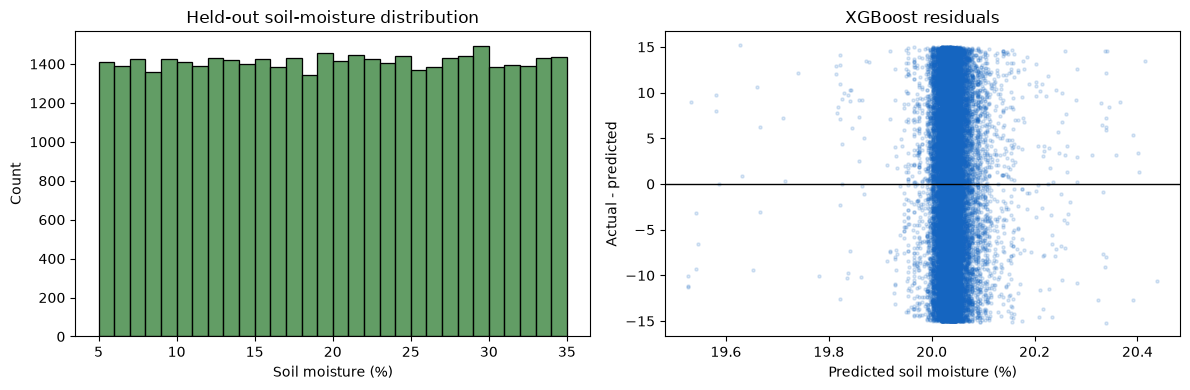

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(y_test, bins=30, ax=axes[0], color='#2E7D32')
axes[0].set_title('Held-out soil-moisture distribution')
axes[0].set_xlabel('Soil moisture (%)')
residuals = y_test.to_numpy() - predictions
axes[1].scatter(predictions, residuals, s=5, alpha=0.15, color='#1565C0')
axes[1].axhline(0, color='black', linewidth=1)
axes[1].set_title('XGBoost residuals')
axes[1].set_xlabel('Predicted soil moisture (%)')
axes[1].set_ylabel('Actual - predicted')
plt.tight_layout()
plt.show()

,importance
Elevation_Data,0.069901
Spatial_Resolution,0.069347
Water_Flow,0.068404
Temperature,0.067604
Organic_Matter,0.066856
Rainfall,0.066821
Soil_pH,0.066368
Humidity,0.064151
NDVI,0.063383
Wind_Speed,0.063316


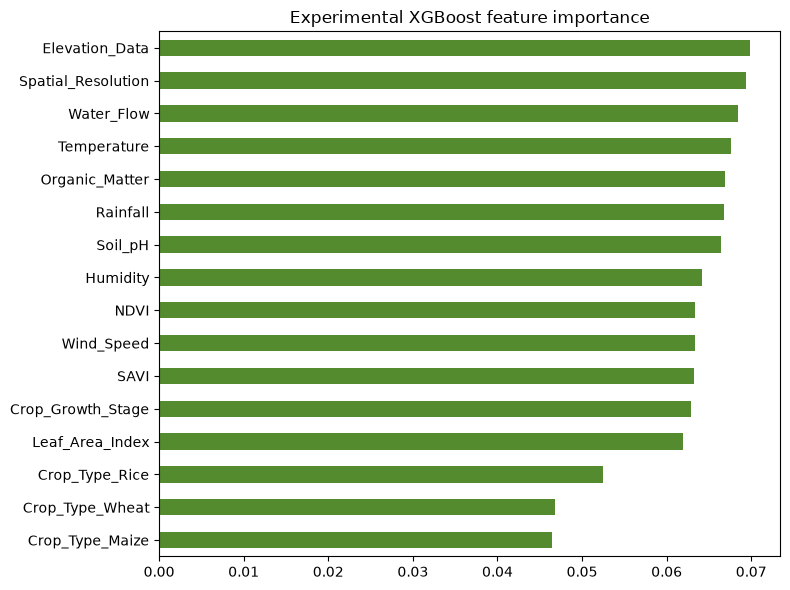

In [10]:
importance = (
    pd.Series(model.feature_importances_, index=X.columns, name='importance')
    .sort_values(ascending=False)
)
display(importance.to_frame())
importance.sort_values().plot.barh(figsize=(8, 6), color='#558B2F')
plt.title('Experimental XGBoost feature importance')
plt.tight_layout()
plt.show()

## 6. Save the experimental artifact and metadata

The artifact is saved for reproducibility even when rejected. Its metadata prevents it from being confused with the production nine-feature model.

In [11]:
model_path = MODEL_DIR / 'agriculture_baseline_xgboost_v1.json'
metadata_path = MODEL_DIR / 'agriculture_baseline_xgboost_v1.metadata.json'
model.save_model(model_path)

dataset_sha256 = hashlib.sha256(DATASET_PATH.read_bytes()).hexdigest()
artifact_sha256 = hashlib.sha256(model_path.read_bytes()).hexdigest()
metadata = {
    'schema_version': 1,
    'model_version': 'agriculture-baseline-xgb-v1',
    'artifact_kind': 'experimental_reduced_feature_baseline',
    'trained_at': datetime.now(timezone.utc).isoformat(),
    'dataset': {
        'filename': DATASET_PATH.name,
        'sha256': dataset_sha256,
        'rows_raw': int(len(df_raw)),
        'rows_used': int(len(df)),
    },
    'artifact_sha256': artifact_sha256,
    'feature_names': list(X.columns),
    'target_name': TARGET,
    'split_strategy': 'random_stratified_target_bins_no_farm_or_time_available',
    'metrics': {
        'median_baseline': dummy_metrics,
        'xgboost': xgb_metrics,
        'relative_mae_improvement': float(relative_mae_improvement),
    },
    'missing_production_fields': missing_contract_fields,
    'promotion_checks': promotion_checks,
    'production_ready': production_ready,
    'limitations': [
        'No farm_id, so held-out-farm validation is impossible.',
        'No observed_at, so temporal leakage cannot be assessed.',
        'No Sentinel-1 VV/VH, EVI, or NDBI.',
        'Near-zero univariate correlations suggest synthetic or randomly generated rows.',
        'This artifact is incompatible with the production SoilMoistureFeatures contract.',
    ],
}
metadata_path.write_text(json.dumps(metadata, indent=2) + '\n', encoding='utf-8')
print(f'Saved model: {model_path}')
print(f'Saved metadata: {metadata_path}')
print(f'PRODUCTION READY: {production_ready}')

Saved model: C:\Users\Lenovo\Desktop\work\KrishiNetra-App\ml\models\agriculture_baseline_xgboost_v1.json
Saved metadata: C:\Users\Lenovo\Desktop\work\KrishiNetra-App\ml\models\agriculture_baseline_xgboost_v1.metadata.json
PRODUCTION READY: False
